In [1]:
import pandas as pd
import string
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler


In [2]:
datadir = '/g/data/w97/mg5624/ABS_project/'

## Partial Dependence

In [3]:
def summarize_ice(df, var_col, y_col="y_hat"):
    """
    Summarize ICE curves by computing mean and percentile bands
    for each unique value of the variable.

    Parameters
    ----------
    df : pd.DataFrame
        Raw ICE dataframe with many rows per variable value.
    var_col : str
        Column name of the ICE variable (e.g., "planting_seas_frost_sum").
    y_col : str
        Column name of the ICE response (default = "y_hat").

    Returns
    -------
    pd.DataFrame
        Summary dataframe with mean and percentile bands.
    """

    percentiles = {
        "5th_percentile": 0.05,
        "15th_percentile": 0.15,
        "25th_percentile": 0.25,
        "35th_percentile": 0.35,
        "65th_percentile": 0.65,
        "75th_percentile": 0.75,
        "85th_percentile": 0.85,
        "95th_percentile": 0.95,
    }

    # Group by the ICE variable value
    grouped = df.groupby(var_col)[y_col]

    # Compute summary stats
    summary = grouped.mean().rename("mean").to_frame()

    for name, q in percentiles.items():
        summary[name] = grouped.quantile(q)

    summary = summary.reset_index()

    return summary


=== Season: PLANTING ===


/scratch/w97/mg5624/tmp/ipykernel_947809/3650537861.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


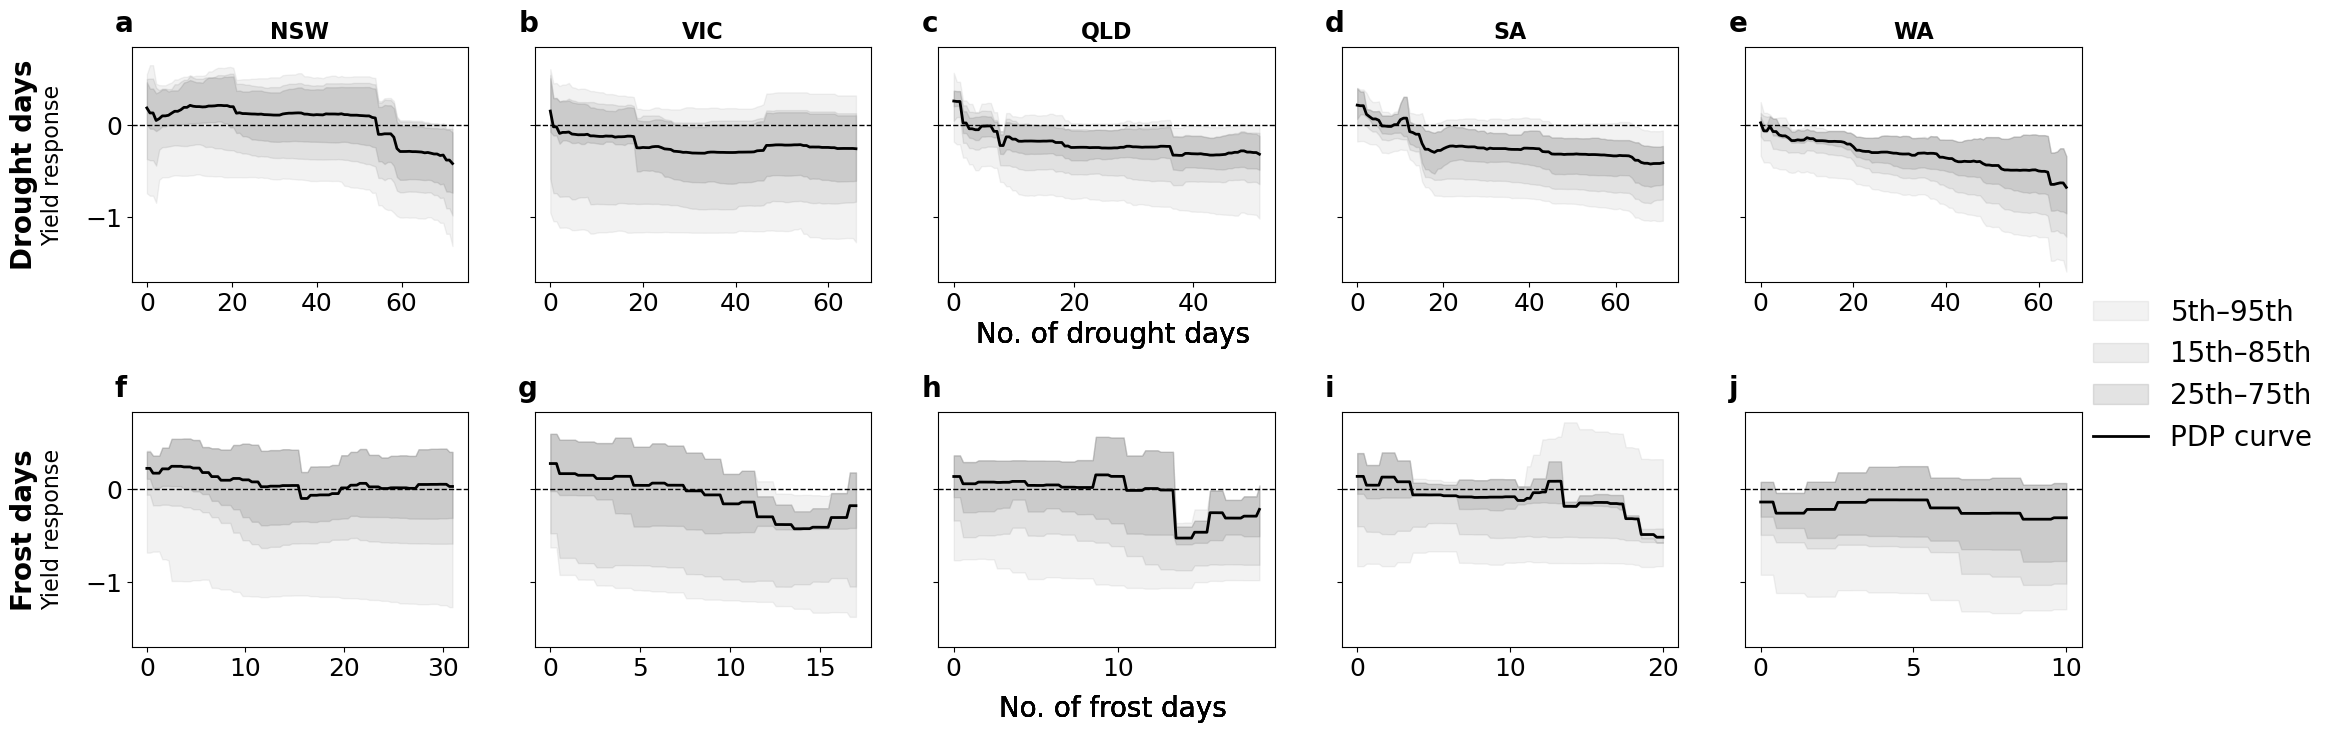


=== Season: MID ===


/scratch/w97/mg5624/tmp/ipykernel_947809/3650537861.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


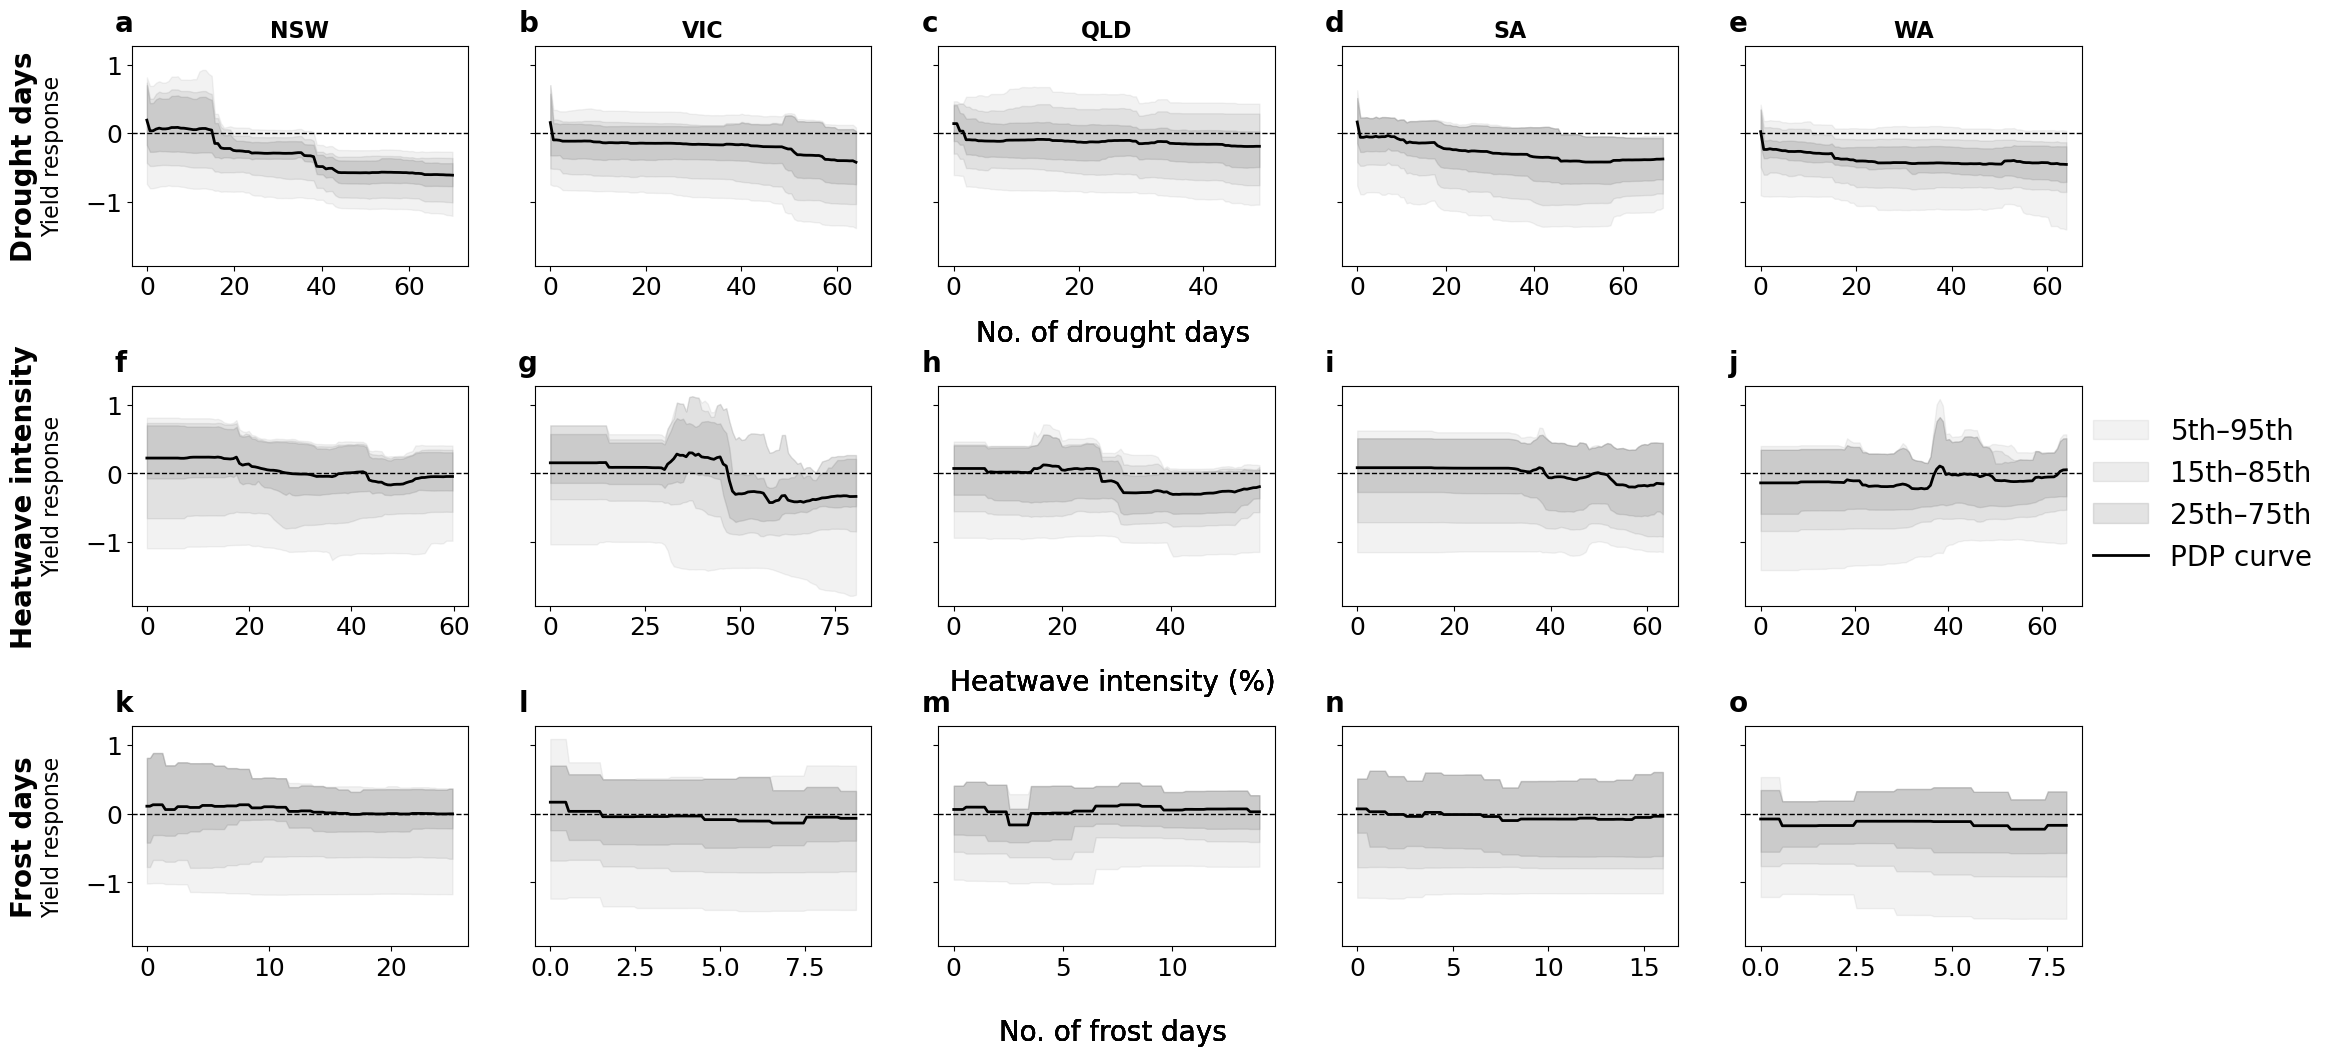


=== Season: HARVEST ===


/scratch/w97/mg5624/tmp/ipykernel_947809/3650537861.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


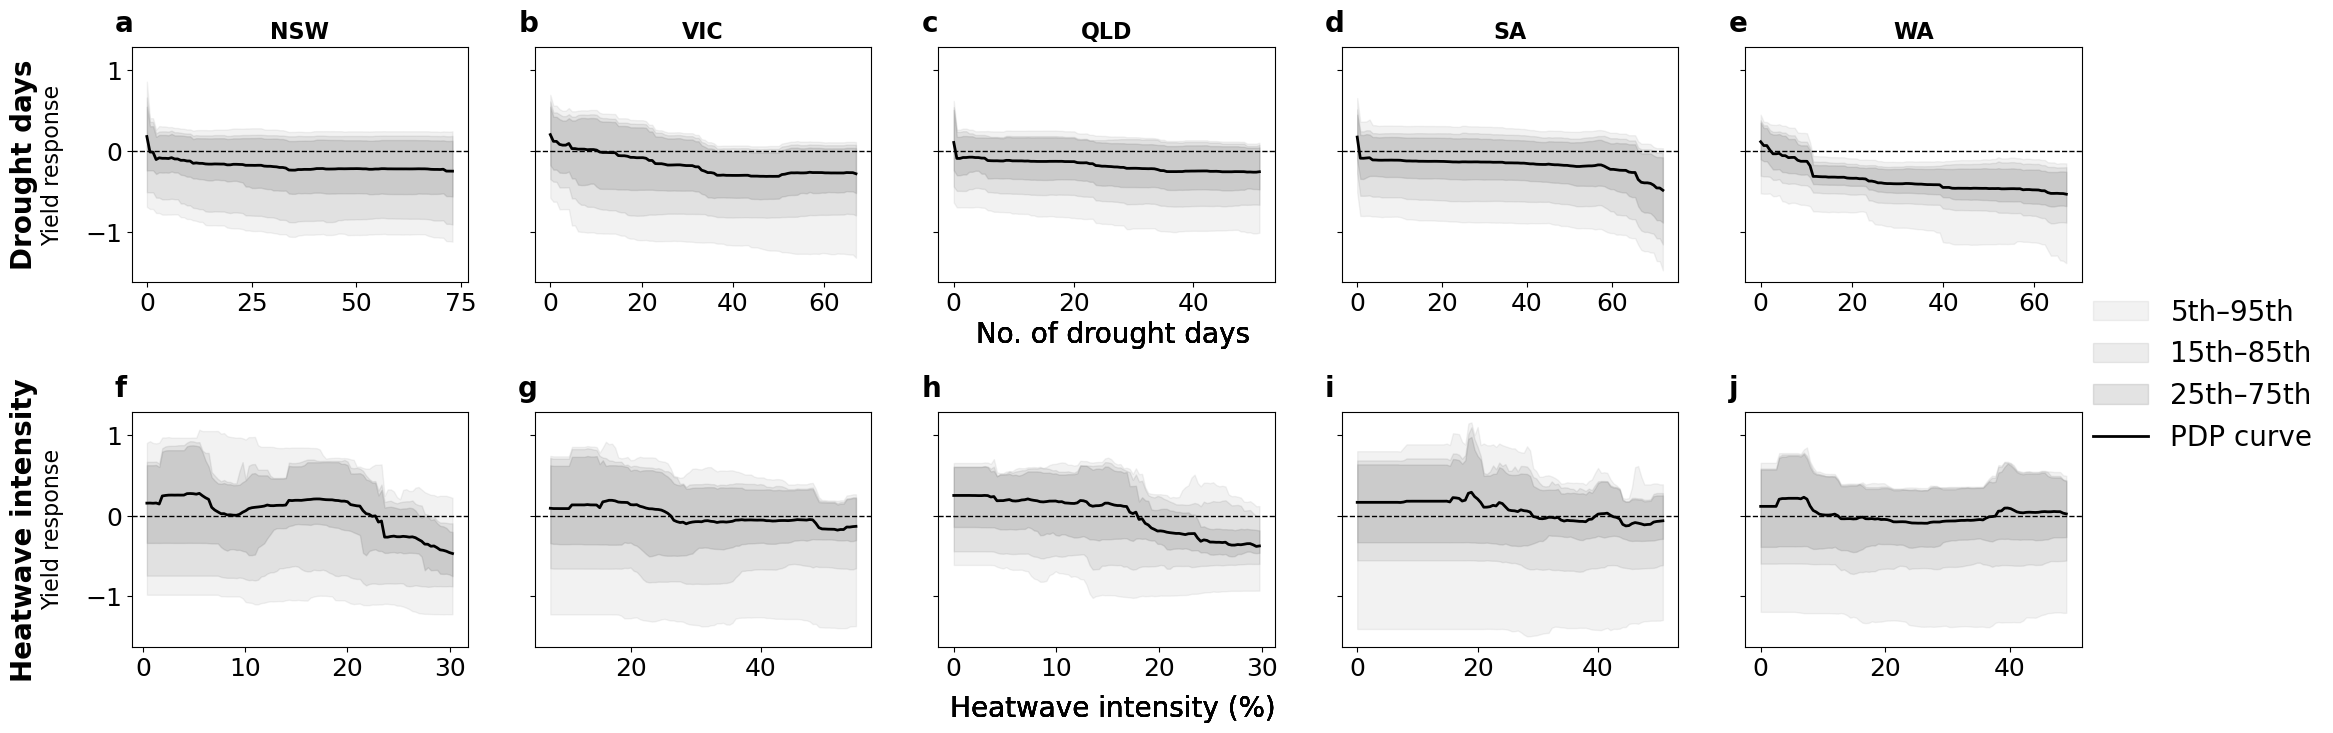

In [4]:
pdp_datadir = f'{datadir}yield_model_analytics/partial_dependence/'

# Seasons and variables — column order per season stage
# (variable file-name keys, in the order they should appear as columns)
season_vars = {
    "planting": [
        "180_day_precip_drought_sum",
        # "180_day_precip_drought_intensity_mean",
        "frost_sum",
    ],
    "mid": [
        "180_day_precip_drought_sum",
        # "180_day_precip_drought_intensity_mean",
        # "heatwave_sum",
        "heatwave_intensity_mean",
        "frost_sum",
    ],
    "harvest": [
        "180_day_precip_drought_sum",
        # "180_day_precip_drought_intensity_mean",
        # "heatwave_sum",
        "heatwave_intensity_mean",
    ],
    # "growing" intentionally omitted — early/mid/late only
}

title_seas = {
    "planting": "Early Season",
    "mid": "Mid Season",
    "harvest": "Late Season",
}

# Friendly x-axis labels for each variable (bottom row only)
var_xlabels = {
    "180_day_precip_drought_sum": "No. of drought days",
    "180_day_precip_drought_intensity_mean": "Drought intensity (%)",
    "frost_sum": "No. of frost days",
    "heatwave_sum": "No. of heatwave days",
    "heatwave_intensity_mean": "Heatwave intensity (%)",
}

# Friendly subplot titles for each variable (top row only)
var_titles = {
    "180_day_precip_drought_sum": "Drought days",
    "180_day_precip_drought_intensity_mean": "Precipitation drought intensity",
    "frost_sum": "Frost days",
    "heatwave_sum": "Heatwave days",
    "heatwave_intensity_mean": "Heatwave intensity",
}

# Row order (top to bottom)
states = [
    'NSW',
    'VIC',
    'QLD',
    'SA',
    'WA',
]

# Uncertainty bands (inner → outer)
bands = [
    ("mean", "5th_percentile",  "95th_percentile", 0.10),
    ("mean", "15th_percentile", "85th_percentile", 0.15),
    ("mean", "25th_percentile", "75th_percentile", 0.22),
    # ("mean", "35th_percentile", "65th_percentile", 0.30)
]

# Legend labels for each band (outer → inner)
band_labels = {
    ("5th_percentile",  "95th_percentile"):  "5th–95th",
    ("15th_percentile", "85th_percentile"):  "15th–85th",
    ("25th_percentile", "75th_percentile"):  "25th–75th",
    # ("35th_percentile", "65th_percentile"):  "35–65%",
}

for season, vars_to_plot in season_vars.items():
    print(f"\n=== Season: {season.upper()} ===")

    n_rows = len(vars_to_plot)
    n_cols = len(states)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharey=True,
        gridspec_kw={'wspace': 0.2, 'hspace': 0.55}
    )

    # Normalize axes to a 2D array regardless of n_rows/n_cols
    axes = np.array(axes).reshape(n_rows, n_cols)

    # Collect legend handles only once (shared across all subplots)
    legend_handles = []
    legend_labels_list = []

    for row, var in enumerate(vars_to_plot):
        for col, state in enumerate(states):
            ax = axes[row, col]

            # --- Subplot letter label, outside axes, top-left ---
            panel_idx = row * n_cols + col
            panel_letter = string.ascii_lowercase[panel_idx]
            ax.text(
                -0.05, 1.04, panel_letter,
                transform=ax.transAxes,
                fontsize=20, fontweight="bold",
                va="bottom", ha="left",
                clip_on=False
            )

            filename = f'{season}_seas_{var}_PDP_RFRegressor_wheat_{state}_extremes_only_{season}_season_only.csv'
            filepath = f"{pdp_datadir}/summaries/{season}_season/{filename}"

            summary_df = pd.read_csv(filepath)
            var_label = f'{season}_seas_{var}'

            # --- Uncertainty bands ---
            for _, low, high, alpha in bands:
                if low in summary_df.columns and high in summary_df.columns:
                    poly = ax.fill_between(
                        summary_df[var_label],
                        summary_df[low],
                        summary_df[high],
                        color="gray",
                        alpha=alpha
                    )

                    # Add legend entry only once
                    key = (low, high)
                    if band_labels[key] not in legend_labels_list:
                        legend_handles.append(poly)
                        legend_labels_list.append(band_labels[key])

            # --- Mean line ---
            mean_line, = ax.plot(
                summary_df[var_label],
                summary_df["mean"],
                color="black",
                linewidth=2,
                label="PDP curve"
            )

            # Add mean curve to legend once
            if "PDP curve" not in legend_labels_list:
                legend_handles.append(mean_line)
                legend_labels_list.append("PDP curve")

            # --- Zero line ---
            ax.axhline(0, color="black", linestyle="--", linewidth=1)

            # --- Column title: state name (top row only) ---
            if row == 0:
                ax.set_title(state, fontsize=16, fontweight="bold")

            # --- X-axis label: one per row, centered across all state columns ---
            # Get the horizontal center across this row's subplots in figure coordinates
            pos_left = axes[row, 0].get_position()
            pos_right = axes[row, -1].get_position()
            x_center = (pos_left.x0 + pos_right.x1) / 2

            fig.text(
                x_center, pos_left.y0 - 0.02,
                var_xlabels.get(var, var),
                ha="center", va="top",
                fontsize=20
            )

        # --- Bold variable label on the left of each row ---
        axes[row, 0].annotate(
            var_titles.get(var, var),
            xy=(-0.32, 0.5),
            xycoords="axes fraction",
            fontsize=20,
            fontweight="bold",
            ha="center",
            va="center",
            rotation=90,
        )

        # --- Y-axis label on every row's first column ---
        axes[row, 0].set_ylabel("Yield response", fontsize=16, labelpad=15)

    # --- Legend in the top-left corner, no box ---
    fig.legend(
        legend_handles,
        legend_labels_list,
        loc="upper left",
        bbox_to_anchor=(0.9, 0.6),
        frameon=False,
        borderaxespad=0.0,
        fontsize=20
    )

    # Extra space on the left so state labels don't overlap the y-axis,
    # and extra space at the top so the legend has its own room above the plots
    # plt.subplots_adjust(left=0.12, top=0.9)
    for ax in axes.flat:
        ax.tick_params(axis='both', labelsize=18)
    plt.tight_layout()
    plt.subplots_adjust(left=0.12, top=0.9, bottom=0.15, hspace=0.45)
    # plt.tight_layout()
    plt.show()

## Full Feature Importance Plots

### Full season, all vars

In [5]:
import re

def transform_name(name):
    if name == 'Random_variable':
        return 'Random Variable'
    stage_map = {
        'growing_seas': ''
    }
    # Pattern: stage_var_sum
    m = re.match(r'^(growing_seas)_(.+?)_(max|sum|intensity_mean|mean)$', name)
    if not m:
        return name  # leave unchanged if it doesn't match the pattern
    
    stage, var, suffix = m.groups()
    new_stage = stage_map[stage]
    var = var.replace('_', ' ')

    if var == '180 day precip drought':
        var = 'precip drought'
    if var == '180 day soil moisture drought':
            var = 'soil moisture drought'
    if suffix == 'sum':
        return f"{new_stage} no. of {var} days"
    elif suffix == 'intensity_mean':
        return f"{new_stage} {var} intensity"
    elif suffix == 'mean':
        return f"mean{new_stage} {var}"
    elif suffix == 'max':
        return f"max{new_stage} {var}"

In [6]:
states = ["NSW", "VIC", "QLD", "SA", "WA"]
full_seas_summaries = {}
import_datadir = f'{datadir}/yield_model_analytics/variable_importance_scores/'
for state in states:
    df = pd.read_csv(f"{import_datadir}/all_vars/full_season/RandomForestRegressor_{state}_permutation_var_import_20agland_norm.csv")   # adjust filename pattern
    
    # Compute stats across seeds (rows)
    mean_imp = df.mean(axis=0)
    min_imp  = df.min(axis=0)
    max_imp  = df.max(axis=0)
    
    summary = pd.DataFrame({
        "mean": mean_imp,
        "min": min_imp,
        "max": max_imp
    })
    
    summary["lower"] = summary["mean"] - summary["min"]
    summary["upper"] = summary["max"] - summary["mean"]
    
    # Sort and keep top 10
    summary = summary.sort_values("mean", ascending=False)
    
    full_seas_summaries[state] = summary

In [7]:
def plot_feature_importance_summaries(summaries, xy_scaling=(7, 4)):
    n_states = len(summaries)
    ncols = 2  # adjust to taste
    nrows = int(np.ceil(n_states / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(xy_scaling[0] * ncols, xy_scaling[1] * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, (letter, (state, summary)) in zip(axes, zip(string.ascii_lowercase, summaries.items())):
        summary_sorted = summary.sort_values("mean")
        summary_sorted.index = summary_sorted.index.map(transform_name)

        ax.barh(
            summary_sorted.index,
            summary_sorted["mean"],
            xerr=[summary_sorted["lower"], summary_sorted["upper"]],
            capsize=4,
            color="steelblue",
            edgecolor="black",
            linewidth=0.6,
        )

        ax.set_xlabel("Feature importance", fontsize=11)
        ax.set_title(state, fontsize=13, fontweight="bold", pad=6)
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=10)
        for tick in ax.get_yticklabels():
            tick.set_rotation(30)

        # panel letter, bold, no brackets, top-left outside axes
        ax.text(
            -0.15, 1.08, letter,
            transform=ax.transAxes,
            fontsize=14, fontweight="bold",
            va="top", ha="left"
        )

    # turn off any unused axes if grid isn't fully filled
    for ax in axes[n_states:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

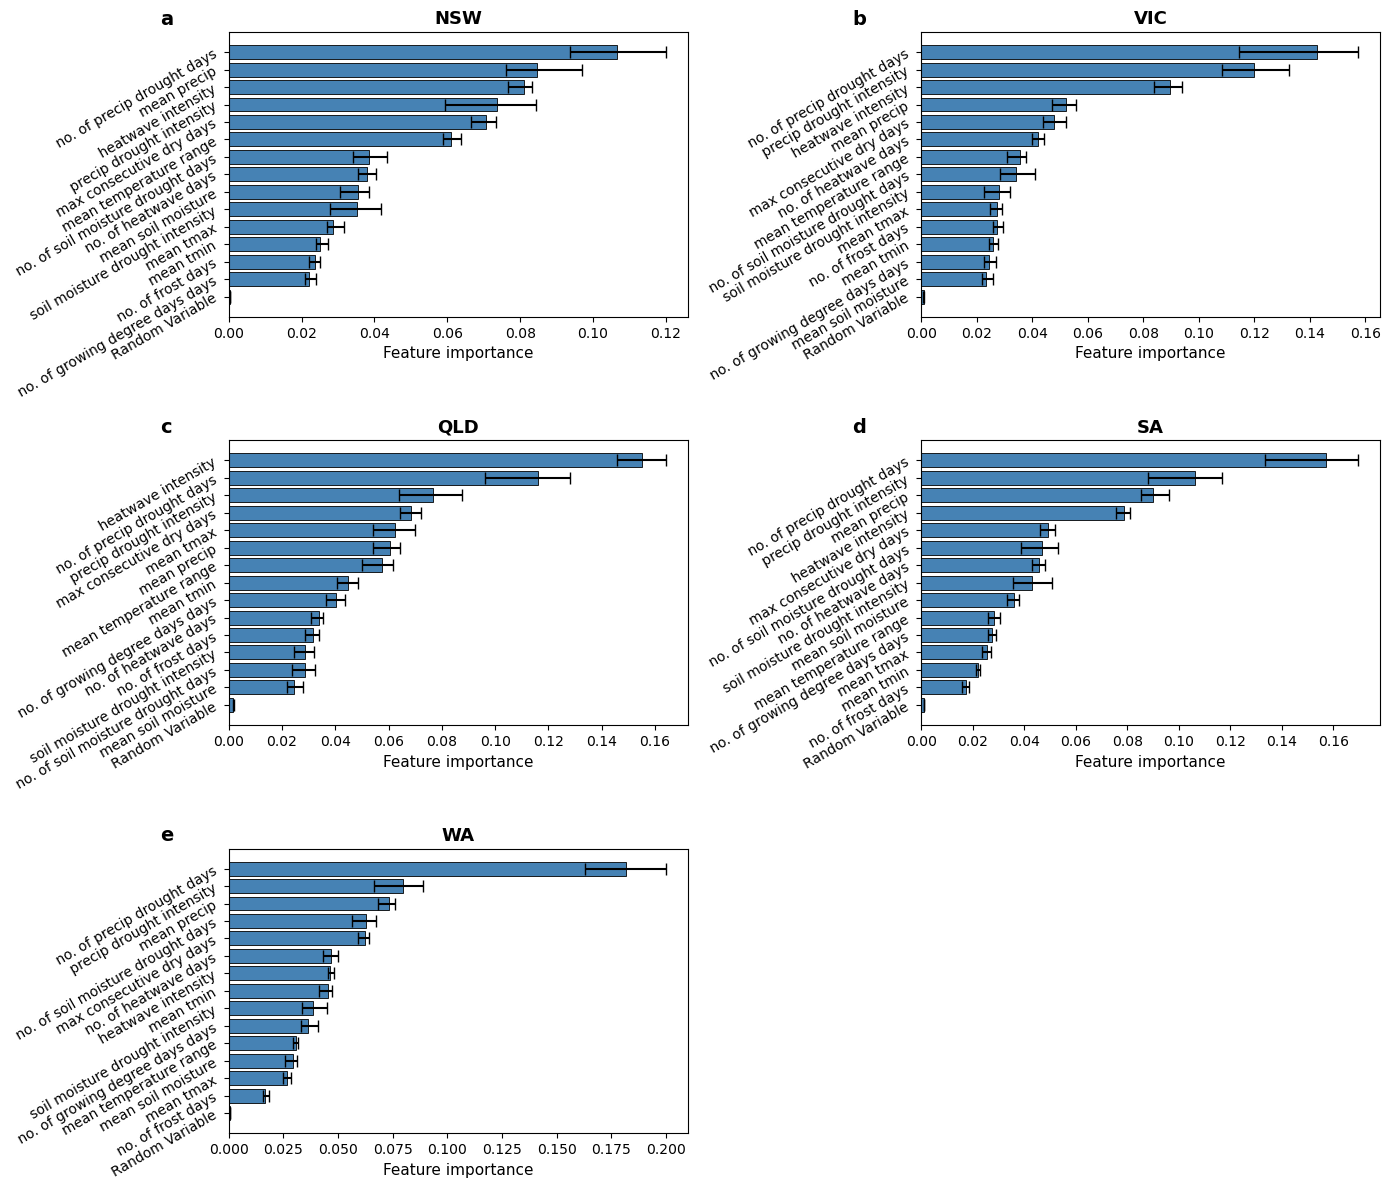

In [8]:
plot_feature_importance_summaries(full_seas_summaries)

### Extremes, sub-seasons

In [9]:
states = ["NSW", "VIC", "QLD", "SA", "WA"]
extremes_summaries = {}
import_datadir = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/variable_importance_scores/'
for state in states:
    df = pd.read_csv(f"{import_datadir}/extremes_only/all_substages/RandomForestRegressor_{state}_permutation_var_import_20agland_norm.csv")   # adjust filename pattern
    
    # Compute stats across seeds (rows)
    mean_imp = df.mean(axis=0)
    min_imp  = df.min(axis=0)
    max_imp  = df.max(axis=0)
    
    summary = pd.DataFrame({
        "mean": mean_imp,
        "min": min_imp,
        "max": max_imp
    })
    
    summary["lower"] = summary["mean"] - summary["min"]
    summary["upper"] = summary["max"] - summary["mean"]
    
    # Sort and keep top 10
    summary = summary.sort_values("mean", ascending=False)#.head(10)
    
    extremes_summaries[state] = summary

In [10]:
def transform_name(name):
    stage_map = {
        'growing_seas': '',
        'harvest_seas': 'Late Season',
        'planting_seas': 'Early Season',
        'mid_seas': 'Mid Season'
    }
    # Pattern: stage_var_sum
    m = re.match(r'^(growing_seas|harvest_seas|planting_seas|mid_seas)_(.+?)_(max|sum|intensity_mean|mean)$', name)
    if not m:
        return name  # leave unchanged if it doesn't match the pattern
    
    stage, var, suffix = m.groups()
    new_stage = stage_map[stage]
    var = var.replace('_', ' ')
    
    if var == '180 day precip drought':
            var = 'precip drought'
    if suffix == 'sum':
        return f"{new_stage} No. of {var} days"
    elif suffix == 'intensity_mean':
        return f"{new_stage} {var} intensity"
    elif suffix == 'mean':
        return f"Mean{new_stage} {var}"
    elif suffix == 'max':
        return f"Max{new_stage} {var}"

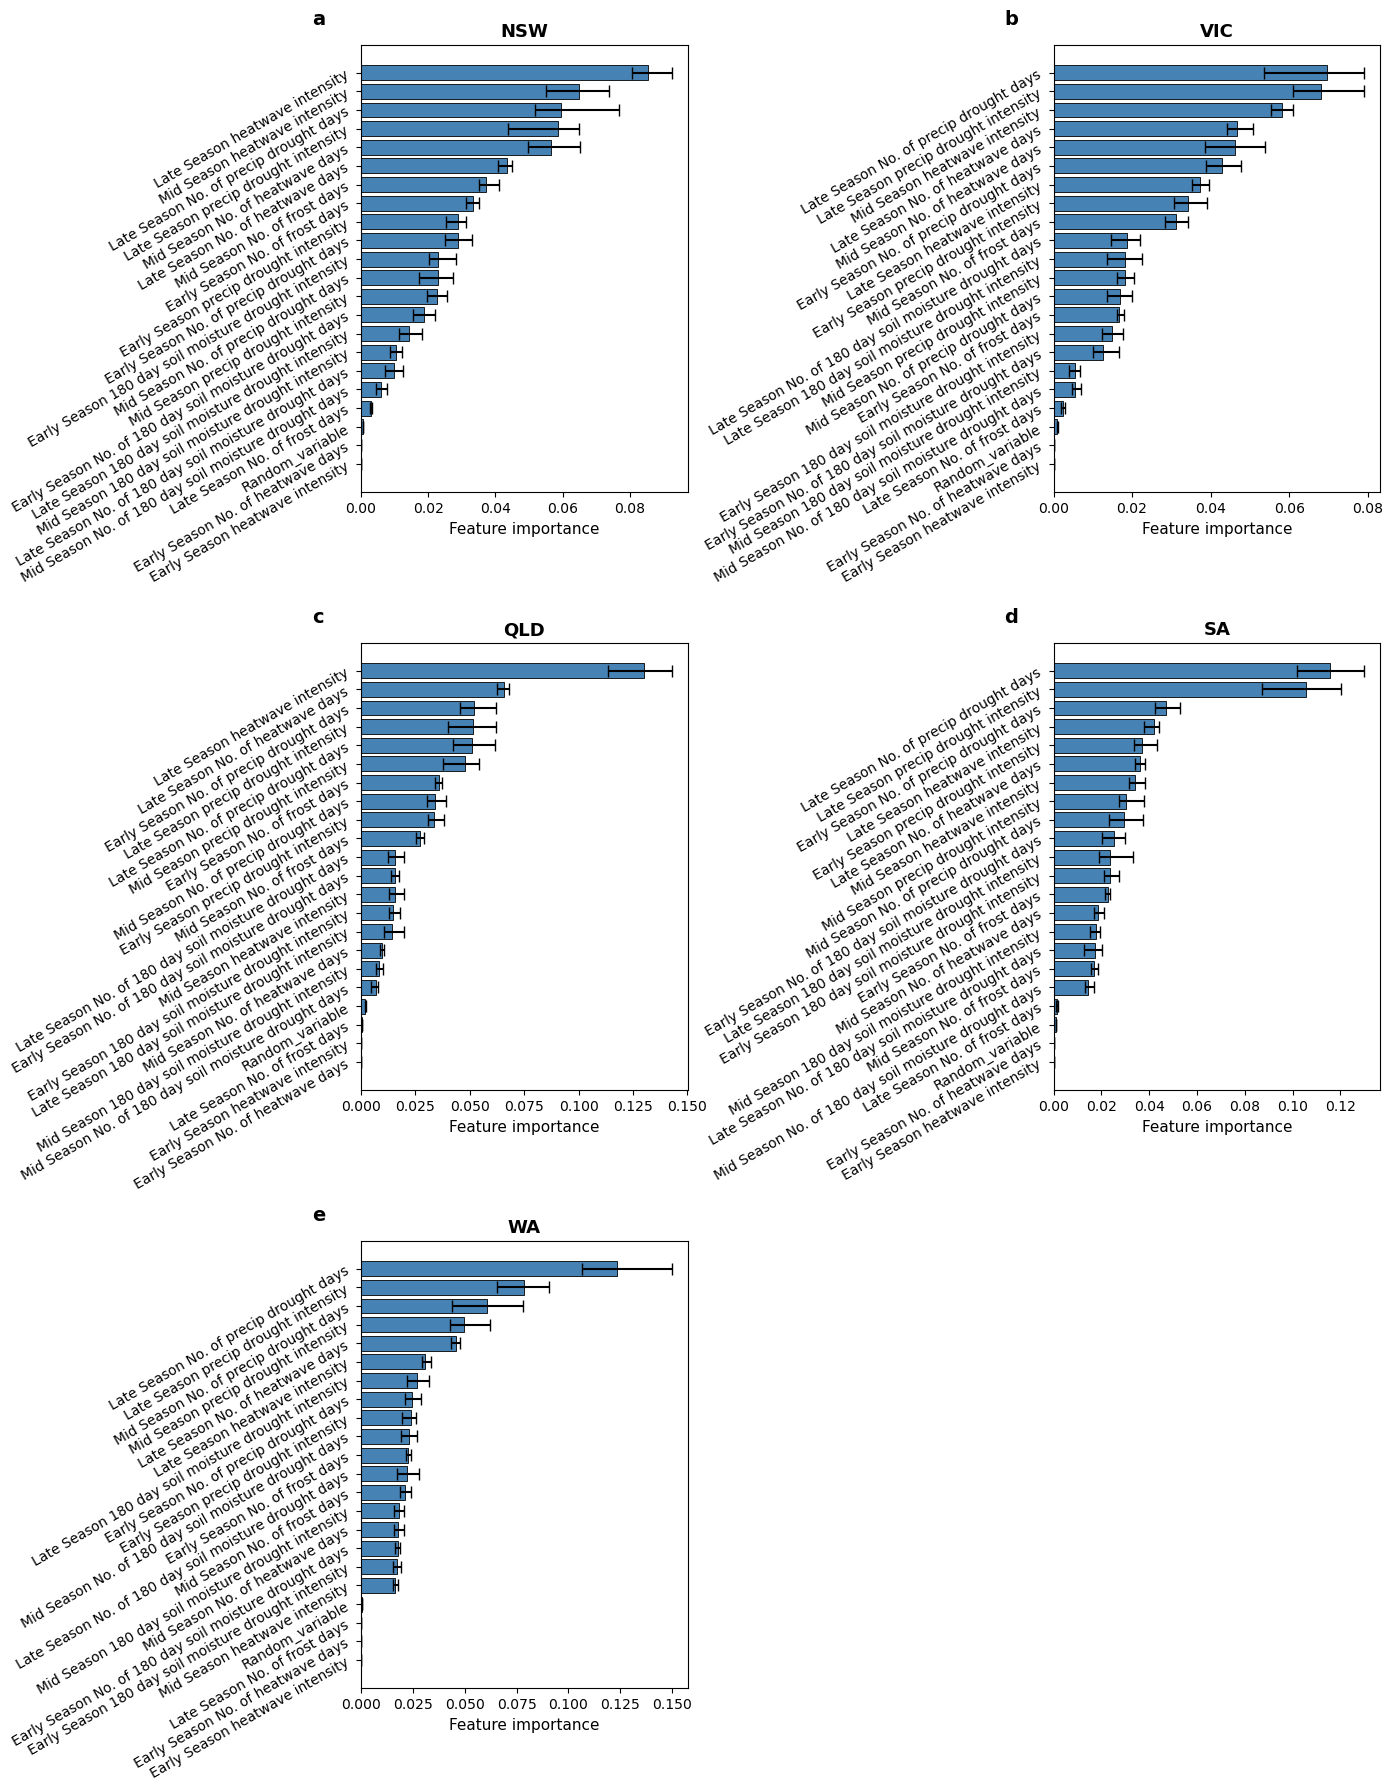

In [11]:
plot_feature_importance_summaries(extremes_summaries, xy_scaling=(7, 6))

## FLAD vs 21st Century Crop

In [12]:
def restandardise(df, new_baseline_years):
    """
    Re-standardise the state yield columns in the dataframe based on a new baseline period.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing state yield columns and a 'year' column.
    new_baseline_years : tuple
        Tuple of (start_year, end_year) for the new baseline period.

    Returns
    -------
    pd.DataFrame
        Dataframe with re-standardised state yield columns.
    """    
    # Fit scaler on new baseline period only
    
    scaler.fit(ref_period[states])
    
    # Apply to full dataframe
    df[states] = scaler.transform(df[states])
    
    return df

In [13]:
ABS_yield_path = '/g/data/w97/mg5624/ABS_project/yield_model_analytics/performance_scores/state_aggregated/all_temp_and_hyd/full_season_only/'
dfs = []
for state in ['AUS', 'NSW', 'QLD', 'VIC', 'SA', 'WA']:
    ABS_yield_file = ABS_yield_path + f'RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    ABS_yield = pd.read_csv(ABS_yield_file)
    ABS_yield = ABS_yield[ABS_yield['seed']==0][['year', 'True']]
    ref_period = ABS_yield[ABS_yield['year'] <= 2017]
    scaler = StandardScaler()
    scaler.fit(ref_period[['True']])
    ABS_yield['True'] = scaler.transform(ABS_yield[['True']])
    ABS_yield = ABS_yield.rename(columns={'True': state})
    dfs.append(ABS_yield)

# Merge all on 'year'
ABS_df = dfs[0]
for df in dfs[1:]:
    ABS_df = ABS_df.merge(df, on='year')

In [14]:
twentieth_cent_data_path = '/g/data/w97/mg5624/ABS_project/twentieth_cent_crop/'
twent_cent_df = pd.read_csv(twentieth_cent_data_path + 'aus_data_sorted.csv', index_col=0)
twent_cent_df = twent_cent_df.rename(columns={'Year':'year'})
twent_cent_df['AUS'] = twent_cent_df[['NSW', 'QLD', 'SA', 'VIC', 'WA']].mean(axis=1)

In [15]:
states = ['AUS', 'NSW', 'QLD', 'SA', 'VIC', 'WA']

# Fit scaler on 2001-2017 period only
ref_period = twent_cent_df[(twent_cent_df['year'] >= 2001) & (twent_cent_df['year'] <= 2017)]
scaler = StandardScaler()
scaler.fit(ref_period[states])

# Apply to full dataframe
twent_cent_df[states] = scaler.transform(twent_cent_df[states])

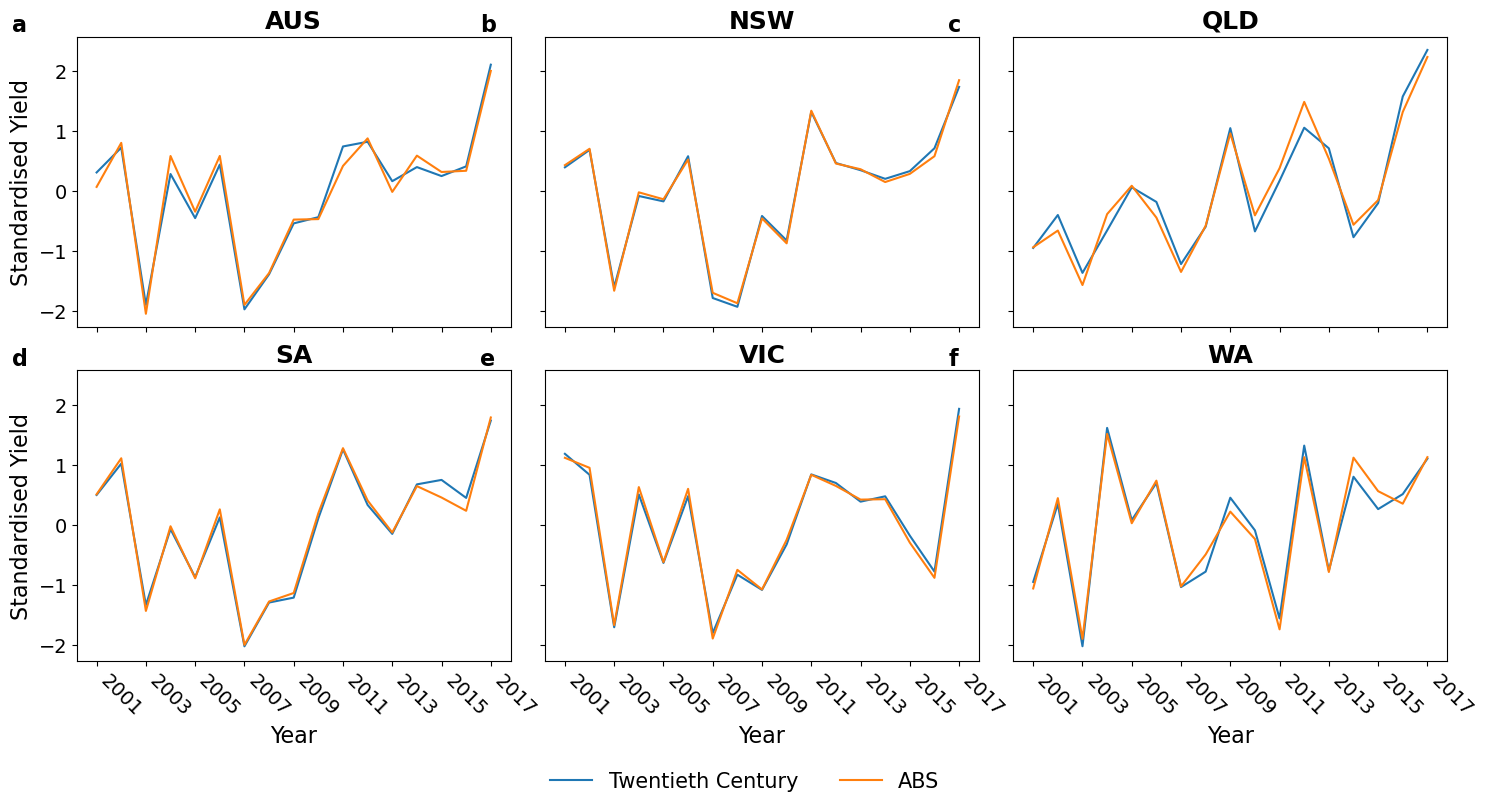

In [16]:
import string

states = ['AUS', 'NSW', 'QLD', 'SA', 'VIC', 'WA']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (state, letter) in enumerate(zip(states, string.ascii_lowercase)):
    ax = axes[i]
    
    # Filter to 2000-2017
    df1_plot = twent_cent_df[(twent_cent_df['year'] >= 2001) & (twent_cent_df['year'] <= 2017)]
    df2_plot = ABS_df[(ABS_df['year'] >= 2001) & (ABS_df['year'] <= 2017)]
    
    line1, = ax.plot(df1_plot['year'], df1_plot[state], label='Twentieth Century')
    line2, = ax.plot(df2_plot['year'], df2_plot[state], label='ABS')
    
    ax.set_title(state, fontsize=18, fontweight='bold')
    ax.tick_params(axis='both', labelsize=14)

    # panel letter, bold, no brackets, top-left outside axes
    ax.text(
        -0.15, 1.08, letter,
        transform=ax.transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="left"
    )

# more x-axis ticks, only need to set once since axes are shared
axes[0].set_xticks(range(2001, 2018, 2))  # every 2 years: 2001, 2003, ..., 2017
for ax in axes[3:]:  # bottom row
    ax.tick_params(axis='x', labelsize=14)
    for label in ax.get_xticklabels():
        label.set_rotation(-45)
        label.set_ha('left')

# shared axis labels only on outer edges
for ax in axes[3:]:          # bottom row
    ax.set_xlabel('Year', fontsize=16)
for ax in axes[::3]:         # left column (indices 0, 3)
    ax.set_ylabel('Standardised Yield', fontsize=16)

# single legend, bottom middle of the whole figure
fig.legend(
    [line1, line2], ['Twentieth Century', 'ABS'],
    loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02),
    frameon=False, fontsize=15
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.subplots_adjust(wspace=0.08, hspace=0.15)
plt.show()

## Average Extremes per Season

In [17]:
import xarray as xr

# Load extreme type
extreme_vars = ['30_day_precip_drought', 'heatwave_intensity', 'frost']
season_stages = ['growing', 'planting', 'mid', 'harvest']

season_label = {
    'growing': 'Full',
    'planting': 'Early',
    'mid': 'Mid',
    'harvest': 'Late',
}

agg = {
    '30_day_precip_drought': 'sum',
    'heatwave_intensity': 'mean',
    'frost': 'sum',
}

for var in extreme_vars:
    ds = xr.open_dataset(f'{datadir}/extremes/FY_aggregated/{var}_FY_agg_1950-2021.nc')
    for season in season_stages:
        da = ds[f'{season}_seas_{var}_{agg[var]}']
        

FileNotFoundError: [Errno 2] No such file or directory: '/g/data/w97/mg5624/ABS_project/extremes/FY_aggregated/30_day_precip_drought_FY_agg_1950-2021.nc'

In [ ]:
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import geopandas as gpd

years_range = slice(1970, 2020)

extreme_vars = ['30_day_precip_drought', 'heatwave_intensity', 'frost']
season_stages = ['growing', 'planting', 'mid', 'harvest']
season_labels = ['Full', 'Early', 'Mid', 'Late']

agg = {
    '30_day_precip_drought': 'sum',
    'heatwave_intensity': 'mean',
    'frost': 'sum',
}

skip_panels = {
    ('Early', 'heatwave_intensity'),
    ('Late', 'frost'),
}

var_cmap_dict = {
    'frost': 'Blues',
    '30_day_precip_drought': 'YlOrBr',
    'heatwave_intensity': 'OrRd',
}

col_titles_dict = {
    'frost': 'Frost Days',
    '30_day_precip_drought': 'Drought Days',
    'heatwave_intensity': 'Heatwave Intensity',
}

cbar_labels_dict = {
    'frost': 'Mean frost days',
    '30_day_precip_drought': 'Mean drought days',
    'heatwave_intensity': 'Mean heatwave intensity (%)',
}

forced_step_dict = {
    'frost': None,
    '30_day_precip_drought': None,
    'heatwave_intensity': 20,
}

N_BINS_TARGET = 8

TITLE_FS  = 20
CBAR_FS   = 17
TICK_FS   = 14

mpl.rcParams['hatch.linewidth'] = 0.35

wheatbelt_nc_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.nc'
wheatbelt_shp_path = '/g/data/w97/mg5624/ABS_project/ag_data/wheatbelt_shapefiles/wheatbelt.shp'
AGCD_mask = xr.open_dataarray('/g/data/w97/mg5624/RF_project/masks/regridded_awra_awap_mask.nc')
wheat_shp = gpd.read_file(wheatbelt_shp_path)

fig, axes = plt.subplots(
    len(season_stages), len(extreme_vars),
    figsize=(5 * len(extreme_vars), 3.5 * len(season_stages)),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# ── First pass: load data, compute mean over 1970-2020 ─────────────────────
all_das = {var: [] for var in extreme_vars}

for var in extreme_vars:
    ds = xr.open_dataset(f'{datadir}/extremes/FY_aggregated/{var}_FY_agg_1950-2021.nc')

    for season, season_label in zip(season_stages, season_labels):
        if (season_label, var) in skip_panels:
            all_das[var].append((season, None))
            continue

        da_var = ds[f'{season}_seas_{var}_{agg[var]}']
        da_var = da_var.sel(time=years_range)

        wheat = xr.open_dataarray(wheatbelt_nc_path).astype(int).interp_like(da_var, method='nearest')
        da_var = da_var.where(wheat.astype(bool))

        da_mean = da_var.mean(dim='time')
        da_mean = da_mean.where(AGCD_mask)

        print(f'Mean {var} in {season} (1970-2020): {float(da_mean.mean().round(2))}')
        all_das[var].append((season, da_mean))

# ── "Nice" regular-interval bin edges ───────────────────────────────────────
def nice_step(raw_step):
    if raw_step <= 0:
        return 1.0
    exponent = np.floor(np.log10(raw_step))
    fraction = raw_step / (10 ** exponent)
    if fraction < 1.5:
        nice_fraction = 1
    elif fraction < 3:
        nice_fraction = 2
    elif fraction < 7:
        nice_fraction = 5
    else:
        nice_fraction = 10
    return nice_fraction * (10 ** exponent)

def get_nice_bin_edges(pooled, n_bins_target, forced_step=None):
    pooled = pooled[~np.isnan(pooled)]
    data_min, data_max = pooled.min(), pooled.max()

    if forced_step is not None:
        step = forced_step
    else:
        raw_step = (data_max - data_min) / n_bins_target
        step = nice_step(raw_step)

    edge_start = np.floor(data_min / step) * step
    edge_end = np.ceil(data_max / step) * step
    edges = np.arange(edge_start, edge_end + step / 2, step)
    return edges, step

def decimals_for_step(step):
    if step >= 1:
        return 0
    elif step >= 0.1:
        return 1
    else:
        return 2

# ── Compute bin edges SEPARATELY for Full season vs. sub-seasons ──────────
bin_edges_dict = {}
decimals_dict = {}
norm_dict = {}
cmap_discrete_dict = {}

for var in extreme_vars:
    full_da = all_das[var][0][1]
    rest_das = [da for _, da in all_das[var][1:] if da is not None]

    full_pooled = full_da.values.flatten()
    rest_pooled = np.concatenate([da.values.flatten() for da in rest_das])

    forced_step = forced_step_dict.get(var)

    full_edges, full_step = get_nice_bin_edges(full_pooled, N_BINS_TARGET, forced_step)
    rest_edges, rest_step = get_nice_bin_edges(rest_pooled, N_BINS_TARGET, forced_step)

    bin_edges_dict[var] = {'full': full_edges, 'rest': rest_edges}
    decimals_dict[var] = {'full': decimals_for_step(full_step), 'rest': decimals_for_step(rest_step)}

    cmap_full = plt.get_cmap(var_cmap_dict[var], len(full_edges) - 1)
    cmap_rest = plt.get_cmap(var_cmap_dict[var], len(rest_edges) - 1)
    cmap_discrete_dict[var] = {'full': cmap_full, 'rest': cmap_rest}

    norm_dict[var] = {
        'full': mpl.colors.BoundaryNorm(full_edges, ncolors=cmap_full.N),
        'rest': mpl.colors.BoundaryNorm(rest_edges, ncolors=cmap_rest.N),
    }

# ── Second pass: plot ────────────────────────────────────────────────────
col_mappables = {var: {'full': None, 'rest': None} for var in extreme_vars}

for row_idx, (season, season_label) in enumerate(zip(season_stages, season_labels)):
    scale_key = 'full' if row_idx == 0 else 'rest'

    for col_idx, var in enumerate(extreme_vars):
        ax = axes[row_idx, col_idx]
        _, da_mean = all_das[var][row_idx]

        if (season_label, var) in skip_panels:
            ax.set_visible(False)
            continue

        norm = norm_dict[var][scale_key]
        cmap = cmap_discrete_dict[var][scale_key]

        for spine in ax.spines.values():
            spine.set_visible(False)

        im = da_mean.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)

        ax.add_feature(cfeature.OCEAN, zorder=100, facecolor='white', edgecolor='k')
        states_provinces = NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines',
            scale='50m', edgecolor='black', facecolor='none', alpha=0.5
        )
        ax.add_feature(states_provinces, linestyle='-', linewidth=1)
        wheat_shp.plot(ax=ax, facecolor='none', edgecolor='darkgreen', linewidth=0.8)

        ax.set_title('')
        ax.set_ylabel('')

        if col_mappables[var][scale_key] is None:
            col_mappables[var][scale_key] = im

# ── Manual layout: row 0 (Full) gets its own colorbar directly below it;    ─
# ── rows 1-3 (Early/Mid/Late) are packed together, with ONE shared         ─
# ── colorbar below the whole figure.                                       ─
fig.canvas.draw()

n_rows = len(season_stages)
n_cols = len(extreme_vars)

left, right = 0.09, 0.99
top = 0.94

h_gap = 0.008
v_gap_sub = 0.008

full_cbar_h = 0.03
gap_after_full_cbar = 0.045

rest_cbar_h = 0.03
bottom_margin = 0.10

total_w = right - left
panel_w = (total_w - h_gap * (n_cols - 1)) / n_cols

available_h = top - bottom_margin

n_row_bands = n_rows
fixed_v_space = full_cbar_h + gap_after_full_cbar + rest_cbar_h + v_gap_sub * (len(season_stages) - 2)
panel_h = (available_h - fixed_v_space) / n_row_bands

# ── Position row 0 (Full) ──
row0_y0 = top - panel_h
for col_idx in range(n_cols):
    ax = axes[0, col_idx]
    x0 = left + col_idx * (panel_w + h_gap)
    ax.set_position([x0, row0_y0, panel_w, panel_h])

# ── Full-season colorbar band, directly below row 0 ──
full_cbar_y = row0_y0 - gap_after_full_cbar - full_cbar_h

# ── Position rows 1-3 (Early/Mid/Late), packed tightly, below the Full cbar band ──
subrows_top = full_cbar_y - 0.06   # bigger gap so panels clear the Full colorbar

for i, row_idx in enumerate(range(1, n_rows)):
    row_y0 = subrows_top - panel_h - i * (panel_h + v_gap_sub)
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        x0 = left + col_idx * (panel_w + h_gap)
        ax.set_position([x0, row_y0, panel_w, panel_h])

last_subrow_y0 = subrows_top - panel_h - (len(season_stages) - 2) * (panel_h + v_gap_sub)
rest_cbar_y = last_subrow_y0 - 0.06

fig.canvas.draw()

grid_x0 = left
grid_x1 = right
grid_y1 = top

# ── Column titles ── just above row 0
title_y = grid_y1 + 0.012
for col_idx, var in enumerate(extreme_vars):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    fig.text(
        x0 + panel_w / 2, title_y,
        col_titles_dict[var],
        ha='center', va='bottom',
        fontsize=TITLE_FS, fontweight='bold'
    )

# ── Row labels ── to the left of each row, pulled in closer to the panels
row_y0_list = [row0_y0] + [
    subrows_top - panel_h - i * (panel_h + v_gap_sub) for i in range(len(season_stages) - 1)
]
label_x = grid_x0 - 0.02   # pulled in closer to panels
for row_idx, season_label in enumerate(season_labels):
    row_center = row_y0_list[row_idx] + panel_h / 2
    fig.text(
        label_x, row_center,
        season_label,
        ha='center', va='center',
        fontsize=TITLE_FS, fontweight='bold',
        rotation=90
    )

# ── Colorbars ──
def add_cbar(fig, im, edges, decimals, col_idx, panel_w, h_gap, grid_x0, cbar_y, label, height=0.013):
    x0 = grid_x0 + col_idx * (panel_w + h_gap)
    cbar_width = panel_w * 0.88
    cbar_x0 = x0 + (panel_w - cbar_width) / 2
    cbar_ax = fig.add_axes([cbar_x0, cbar_y, cbar_width, height])
    cbar_obj = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='neither', ticks=edges)

    fmt = f'{{:.{decimals}f}}'
    cbar_obj.ax.set_xticklabels([fmt.format(e) for e in edges])
    cbar_obj.ax.tick_params(labelsize=TICK_FS, rotation=45)
    cbar_obj.set_label(label, fontsize=CBAR_FS, labelpad=8)
    return cbar_ax

for col_idx, var in enumerate(extreme_vars):
    # Full-season colorbar — directly below row 0
    im_full = col_mappables[var]['full']
    if im_full is not None:
        edges_full = bin_edges_dict[var]['full']
        dec_full = decimals_dict[var]['full']
        add_cbar(fig, im_full, edges_full, dec_full, col_idx, panel_w, h_gap, grid_x0, full_cbar_y, cbar_labels_dict[var])

    # Shared Early/Mid/Late colorbar — at the bottom of the whole figure
    im_rest = col_mappables[var]['rest']
    if im_rest is not None:
        edges_rest = bin_edges_dict[var]['rest']
        dec_rest = decimals_dict[var]['rest']
        add_cbar(fig, im_rest, edges_rest, dec_rest, col_idx, panel_w, h_gap, grid_x0, rest_cbar_y, cbar_labels_dict[var])

plt.show()

## Model Evaluation Plots

In [ ]:
## Load data for model eval
## Need: gird-level perf, aggregated yields, gridded r2 scores
perf_datadir = f'{datadir}/yield_model_analytics/performance_scores/'
full_seas_perf_scores = pd.read_csv(f'{perf_datadir}grid_level/various_vars/full_season_only/RandomForestRegressor_various_vars_full_season_only_100_model_performance_scores.csv')
eval_r2 = full_seas_perf_scores[full_seas_perf_scores['variables'] == 'all_temp_and_hyd']
# Compute summary stats per state
summary = eval_r2.groupby("area")["r2"].agg(["median", "min", "max"])

# Error bar sizes
lower = summary["median"] - summary["min"]
upper = summary["max"] - summary["median"]

# Plot
plt.figure(figsize=(8,5))
plt.bar(summary.index, summary["median"], yerr=[lower, upper], capsize=5)

plt.ylabel("R²", fontsize=15)
# plt.title("R² Values Between Withheld Predicted and Observed Yields by State", fontsize=15)
plt.tight_layout()
plt.show()




In [ ]:
states = ["AUS", "NSW", "VIC", "QLD", "SA", "WA"]

results = []

for state in states:
    df = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )
    
    # Compute Pearson r² for each seed
    r2_by_seed = (
        df.groupby("seed")
          .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
          .reset_index(name="r2")
    )
    
    r2_by_seed["state"] = state
    results.append(r2_by_seed)

# Combine all states
r2_df = pd.concat(results, ignore_index=True)

In [ ]:
summary = (
    r2_df.groupby("state")["r2"]
         .agg(["median", "min", "max"])
)
lower = summary["median"] - summary["min"]
upper = summary["max"] - summary["median"]
print(summary)
plt.figure(figsize=(8,5))

plt.bar(summary.index, summary["median"], yerr=[lower, upper], capsize=5)

plt.ylabel("R²", fontsize=15)
# plt.title("Aggregated R² per State")
plt.tight_layout()
plt.show()


In [ ]:
def r2_value(y_true, y_pred):
    correlation = np.corrcoef(y_true, y_pred)[0, 1]
    return correlation ** 2

## Added explained variance from extremes

In [ ]:
states = ["AUS", "NSW", "VIC", "QLD", "SA", "WA"]

all_results = []

for state in states:
    df = pd.read_csv(
        f'{perf_datadir}/state_aggregated/all_temp_and_hyd/full_season_only/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )
    
    # Compute Pearson r² for each seed
    r2_by_seed = (
        df.groupby("seed")
          .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
          .reset_index(name="r2")
    )
    
    r2_by_seed["state"] = state
    all_results.append(r2_by_seed)

# Combine all states
all_r2_df = pd.concat(all_results, ignore_index=True)

In [ ]:
nonex_results = []

for state in states:
    df = pd.read_csv(
        f'{perf_datadir}/state_aggregated/clim_only/full_season_only/RandomForestRegressor_{state}_predicted_vs_true_yield_yearsplit_20agland_norm.csv'
    )
    
    # Compute Pearson r² for each seed
    r2_by_seed = (
        df.groupby("seed")
          .apply(lambda g: g["True"].corr(g["Predicted"]) ** 2)
          .reset_index(name="r2")
    )
    
    r2_by_seed["state"] = state
    nonex_results.append(r2_by_seed)

# Combine all states
nonex_r2_df = pd.concat(nonex_results, ignore_index=True)

In [ ]:
all_r2 = all_r2_df.pivot(index='seed', columns='state', values='r2')
nonex_r2 = nonex_r2_df.pivot(index='seed', columns='state', values='r2')

In [ ]:
diff_r2 = all_r2.mean() - nonex_r2.mean()

print(diff_r2)

## Modelled Yield to 2025

In [18]:
from sklearn.preprocessing import StandardScaler
states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

In [19]:
modelled_yield_path = f'{datadir}yield_model_analytics/modelled_yield/past_yield/all_states_modelled_annual_avg_yield.csv'
modelled_yield_path_2022_25 = f'{datadir}yield_model_analytics/modelled_yield/past_yield/all_states_modelled_annual_avg_yield_2022-2025.csv'

modelled_yield_df = pd.read_csv(modelled_yield_path)
modelled_yield_df_2022_25 = pd.read_csv(modelled_yield_path_2022_25)

modelled_yield_df = pd.concat([modelled_yield_df, modelled_yield_df_2022_25], ignore_index=True)
modelled_yield = modelled_yield_df[(modelled_yield_df['year'] >= 1970) & (modelled_yield_df['year'] <= 2025)]
modelled_yield = modelled_yield.pivot(index='year', columns='state', values='predicted_yield').reset_index()

ref_period = modelled_yield[(modelled_yield['year'] >= 2001) & (modelled_yield['year'] <= 2017)]
scaler = StandardScaler()
scaler.fit(ref_period[states])

# Apply to full dataframe
modelled_yield[states] = scaler.transform(modelled_yield[states])

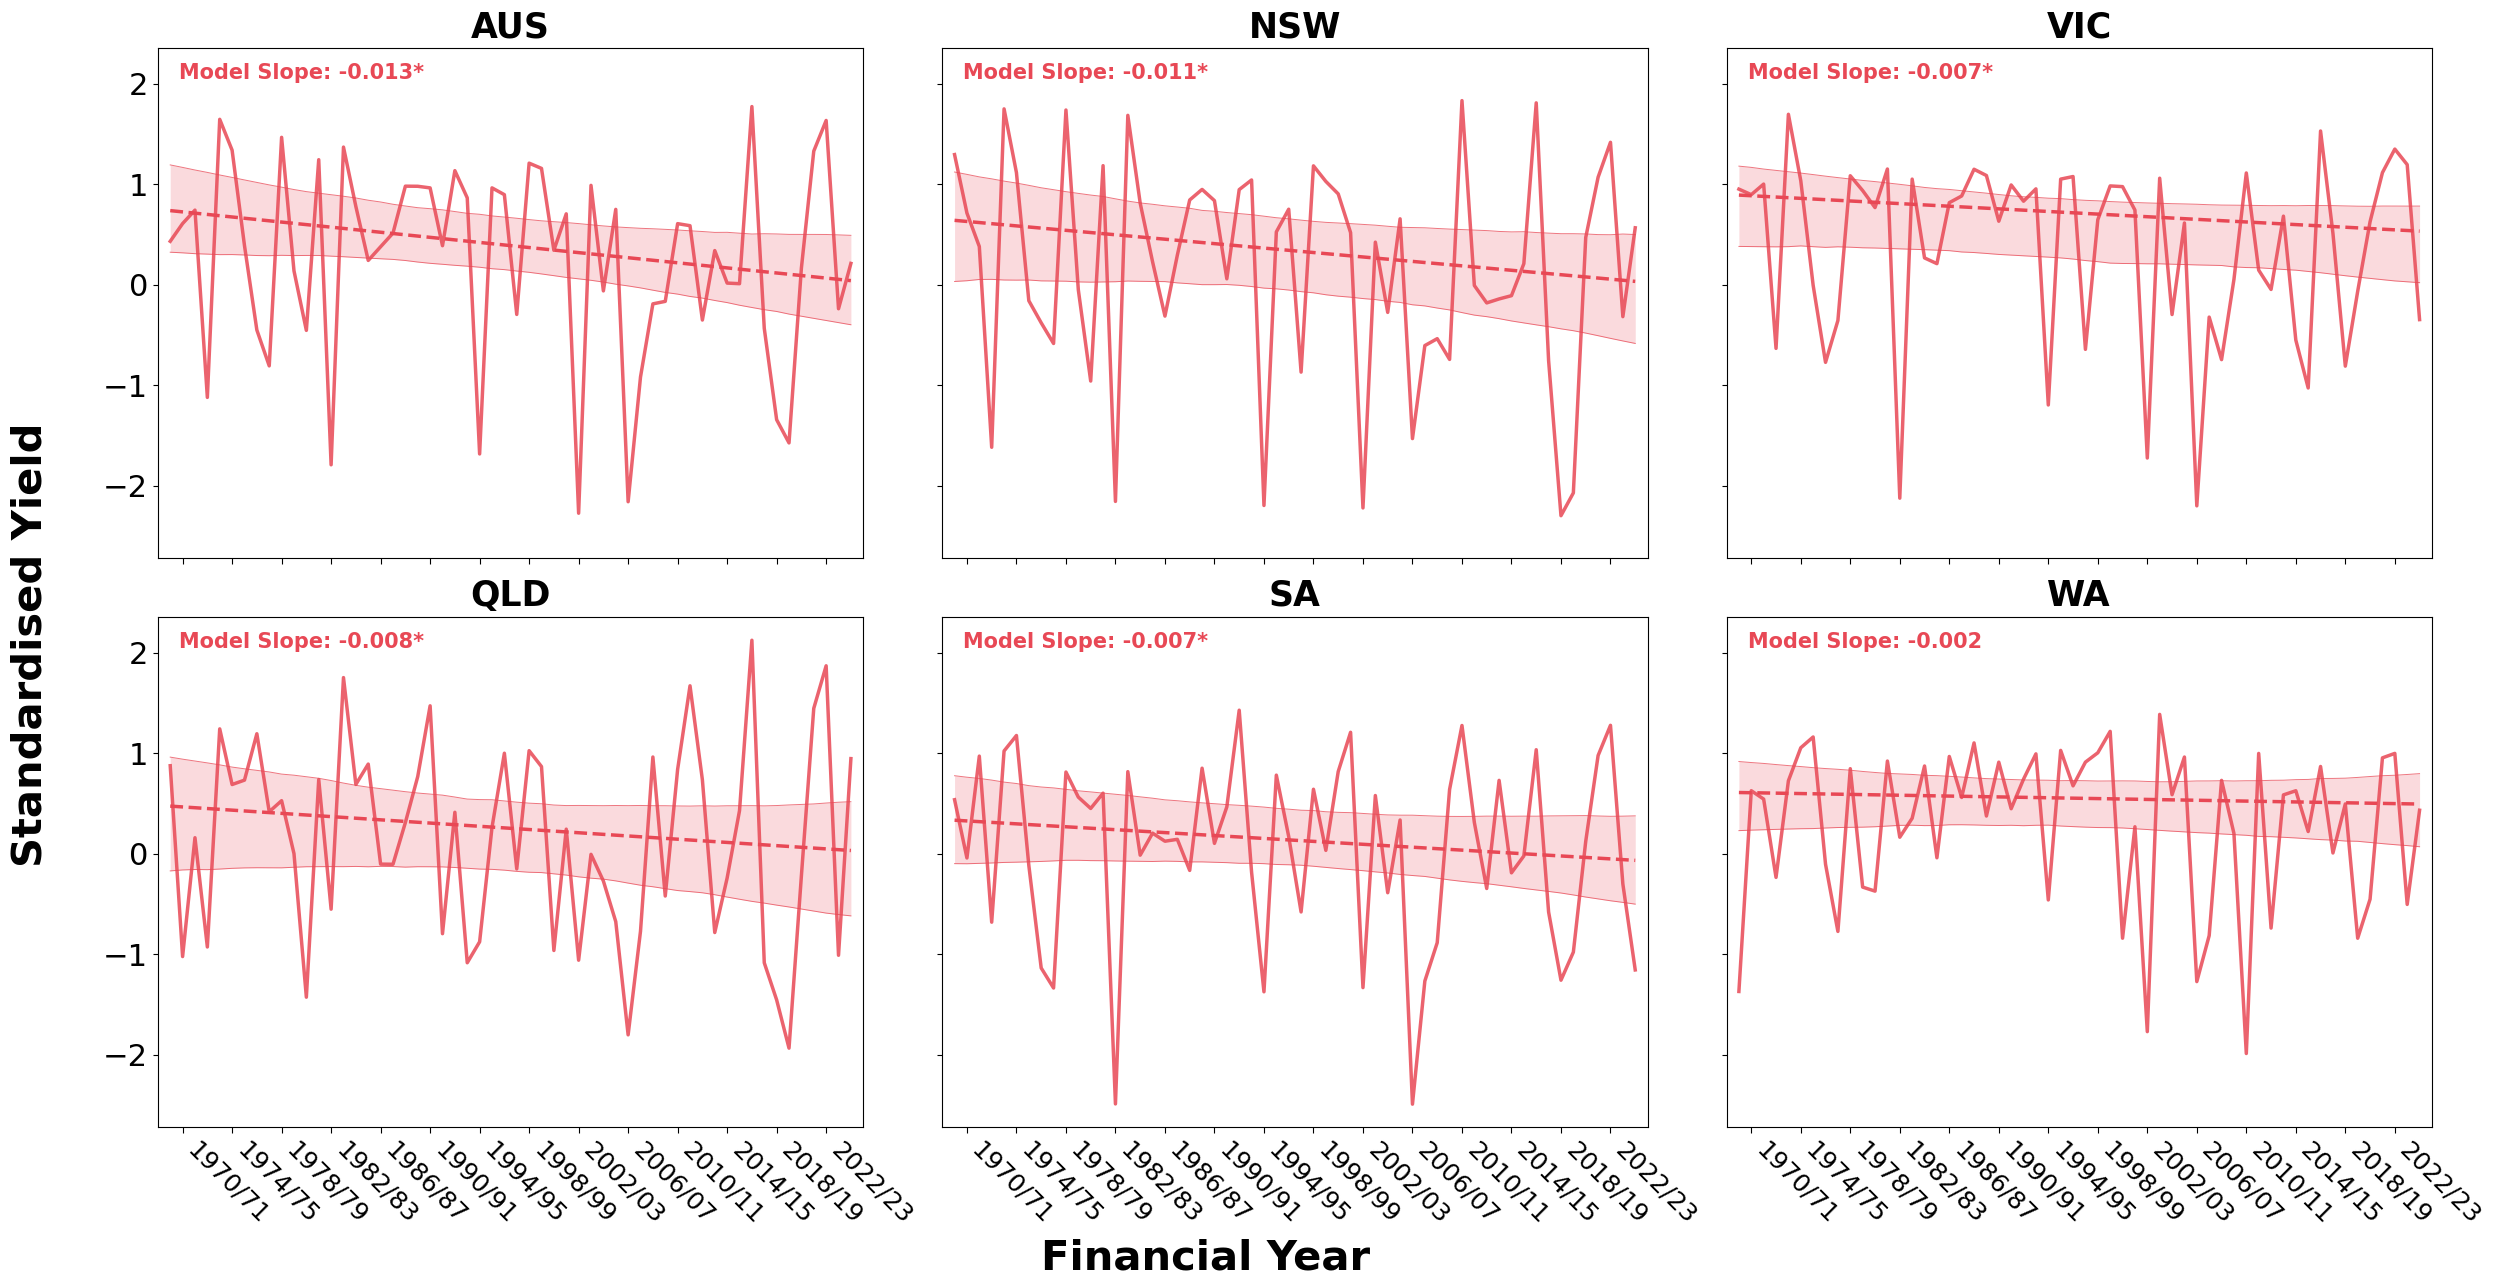

In [23]:
import pymannkendall as mk
import numpy as np
# Palette
col_twent = "#A9C6E8"   # light blue - twentieth century obs
col_abs   = "#2E86AB"   # blue - obs (FLAD/ABS)
col_model = "#E84855"   # reddish - modelled


def bootstrap_slope_intercept(y, n_boot=1000, random_state=None):
    """Residual bootstrap of Yue-Wang Theil-Sen slope/intercept for a 1D array."""
    rng = np.random.default_rng(random_state)
    n = len(y)
    x = np.arange(n)

    base = mk.yue_wang_modification_test(y)
    slope0, intercept0 = base.slope, base.intercept
    fitted = slope0 * x + intercept0
    residuals = y - fitted

    boot_slopes = np.empty(n_boot)
    boot_intercepts = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_boot = fitted + residuals[idx]
        res = mk.yue_wang_modification_test(y_boot)
        boot_slopes[i] = res.slope
        boot_intercepts[i] = res.intercept

    return slope0, intercept0, base.trend, boot_slopes, boot_intercepts


def bootstrap_band(x, slope0, intercept0, boot_slopes, boot_intercepts, ci=95):
    """
    Direct (non-pivoted) bootstrap uncertainty band: evaluate every
    bootstrapped (slope, intercept) line across x, then take percentiles
    at each x. Because slope and intercept are correlated across
    bootstrap draws, this band is not perfectly linear/fan-shaped -- it
    can flex slightly along x, unlike a band pivoted through one fixed point.
    """
    trendline = slope0 * x + intercept0
    lo_pct, hi_pct = (100 - ci) / 2, 100 - (100 - ci) / 2
    boot_lines = boot_slopes[:, None] * x[None, :] + boot_intercepts[:, None]
    lower = np.percentile(boot_lines, lo_pct, axis=0)
    upper = np.percentile(boot_lines, hi_pct, axis=0)
    return trendline, lower, upper

states = ['AUS', 'NSW', 'VIC', 'QLD', 'SA', 'WA']

n_boot = 1000
full_years = np.arange(1971, 2025)

fig, axes = plt.subplots(2, 3, figsize=(26, 13), sharex=True, sharey=True)
axes = axes.flatten()

for ax, state in zip(axes, states):
    # abs_vals = ABS_df[state].values
    # twent_vals = twent_cent_df[state].values
    model_vals = modelled_yield[state].values

    # twent_years = twent_cent_df['year']
    # abs_years = ABS_df['year']
    model_years = modelled_yield['year']

    tick_years = full_years[::4]
    tick_labels = [f"{y-1}/{str(y)[-2:]}" for y in tick_years]

    # slope_twent, intercept_twent, trend_twent, bs_twent, bi_twent = bootstrap_slope_intercept(
    #     twent_vals, n_boot=n_boot, random_state=42)
    # slope_abs, intercept_abs, trend_abs, bs_abs, bi_abs = bootstrap_slope_intercept(
    #     abs_vals, n_boot=n_boot, random_state=42)
    slope_model, intercept_model, trend_model, bs_model, bi_model = bootstrap_slope_intercept(
        model_vals, n_boot=n_boot, random_state=42)

    # sig_twent = trend_twent != "no trend"
    # sig_abs = trend_abs != "no trend"
    sig_model = trend_model != "no trend"

    # x_twent = np.arange(len(twent_years))
    # x_abs = np.arange(len(abs_years))
    x_model = np.arange(len(model_years))

    # twent_trend, twent_lower, twent_upper = bootstrap_band(x_twent, slope_twent, intercept_twent, bs_twent, bi_twent)
    # abs_trend, abs_lower, abs_upper = bootstrap_band(x_abs, slope_abs, intercept_abs, bs_abs, bi_abs)
    model_trend, model_lower, model_upper = bootstrap_band(x_model, slope_model, intercept_model, bs_model, bi_model)

    # observed series
    # ax.plot(twent_years, twent_vals, color=col_twent, linewidth=2.5, alpha=0.85)
    # ax.plot(abs_years, abs_vals, color=col_abs, linewidth=2.5, alpha=0.85)
    ax.plot(model_years, model_vals, color=col_model, linewidth=2.5, alpha=0.85)

    # trendlines
    # ax.plot(twent_years, twent_trend, color=col_twent, linewidth=2.5, linestyle="--")
    # ax.plot(abs_years, abs_trend, color=col_abs, linewidth=2.5, linestyle="--")
    ax.plot(model_years, model_trend, color=col_model, linewidth=2.5, linestyle="--")

    # bootstrap uncertainty bands (curved, direct percentile of bootstrapped lines)
    # ax.fill_between(twent_years, twent_lower, twent_upper, color=col_twent, alpha=0.2, linewidth=0)
    # ax.fill_between(abs_years, abs_lower, abs_upper, color=col_abs, alpha=0.2, linewidth=0)
    ax.fill_between(model_years, model_lower, model_upper, color=col_model, alpha=0.2, linewidth=0)

    # thin border lines on the bands
    # ax.plot(twent_years, twent_lower, color=col_twent, linewidth=0.7, alpha=0.75)
    # ax.plot(twent_years, twent_upper, color=col_twent, linewidth=0.7, alpha=0.75)
    # ax.plot(abs_years, abs_lower, color=col_abs, linewidth=0.7, alpha=0.75)
    # ax.plot(abs_years, abs_upper, color=col_abs, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_lower, color=col_model, linewidth=0.7, alpha=0.75)
    ax.plot(model_years, model_upper, color=col_model, linewidth=0.7, alpha=0.75)

    # sig_marker_twent = "*" if sig_twent else ""
    # sig_marker_abs = "*" if sig_abs else ""
    sig_marker_model = "*" if sig_model else ""
    # text_twent = f"20thC Slope: {slope_twent:.3f}{sig_marker_twent}"
    # text_abs = f"FLAD Slope: {slope_abs:.3f}{sig_marker_abs}"
    text_model = f"Model Slope: {slope_model:.3f}{sig_marker_model}"

    # ax.text(0.03, 0.97, text_twent, color=col_twent,
    #         fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    # ax.text(0.03, 0.90, text_abs, color=col_abs,
            # fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")
    ax.text(0.03, 0.97, text_model, color=col_model,
            fontsize=15, va="top", ha="left", transform=ax.transAxes, fontweight="bold")

    ax.set_title(state, fontsize=25, fontweight="bold", pad=8)
    ax.set_xlim(1969, 2026)
    ax.set_xticks(tick_years)
    ax.set_xticklabels(tick_labels, rotation=-45, ha='left', fontsize=18)
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', which='both', length=4)

fig.text(0.5, 0.02, "Financial Year", ha='center', fontsize=30, fontweight="bold")
fig.text(0.04, 0.5, "Standardised Yield",
         va='center', rotation='vertical', fontsize=30, fontweight="bold")

plt.tight_layout(rect=[0.07, 0.04, 1, 1])
# plt.savefig("/home/claude/publication_style_3series_bootstrap.png", dpi=150, bbox_inches="tight")
